# Optimización de hyperparametros

In [5]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    )

from src.Routes import RUTAS
import src.hyperparameter_tuning as hyperparameter_tuning

hyperparameter_tuning = importlib.reload(hyperparameter_tuning)
optimize_random_forest = hyperparameter_tuning.optimize_random_forest
optimize_random_forest_v2 = hyperparameter_tuning.optimize_random_forest_v2
optimize_random_forest_v3 = hyperparameter_tuning.optimize_random_forest_v3
optimize_random_forest_v3_fast = hyperparameter_tuning.optimize_random_forest_v3_fast
optimize_random_forest_v4 = hyperparameter_tuning.optimize_random_forest_v4
optimize_random_forest_v5 = hyperparameter_tuning.optimize_random_forest_v5
build_v5_engineered_features = hyperparameter_tuning.build_v5_engineered_features
get_v5_feature_sets = hyperparameter_tuning.get_v5_feature_sets

In [3]:
path_archivo_codificado = RUTAS['data_processed'] / 'Sales_Marketing_Clean_(Codificado).csv'

df = pd.read_csv(path_archivo_codificado)

nombre_target = 'subscription_type'
y = df[nombre_target]
X = df.drop(columns=[nombre_target], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

df.columns

Index(['age', 'total_spent', 'avg_order_value', 'lifetime_value',
       'last_3_month_purchase_freq', 'marketing_spend_per_user',
       'total_visits', 'avg_session_time', 'pages_per_session',
       'email_open_rate', 'email_click_rate', 'support_tickets',
       'delivery_delay_days', 'satisfaction_score', 'nps_score', 'gender',
       'country', 'acquisition_channel', 'subscription_type',
       'payment_method'],
      dtype='str')

In [42]:
mejor_modelo_grid = optimize_random_forest(X_train, y_train)

mejor_pipeline = mejor_modelo_grid.best_estimator_

y_pred = mejor_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

from sklearn.metrics import roc_auc_score

probs = mejor_pipeline.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, probs)

print("ROC AUC:", auc)

Buscando mejores hiperparámetros...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Mejores parámetros:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Mejor ROC-AUC CV: 0.6207
              precision    recall  f1-score   support

           0       0.55      0.52      0.53      1544
           1       0.56      0.59      0.57      1606

    accuracy                           0.55      3150
   macro avg       0.55      0.55      0.55      3150
weighted avg       0.55      0.55      0.55      3150

ROC AUC: 0.6094051452132224


In [43]:
print('INFORME V1 - AJUSTE DEL MODELO')
print('Se ajustó el modelo Random Forest base con los siguientes hiperparámetros:')
print(mejor_modelo_grid.best_params_)
print(f"Resultado en test: ROC AUC = {auc:.4f}")
print('Interpretación: esta versión funciona como línea base para comparar mejoras posteriores.')

INFORME V1 - AJUSTE DEL MODELO
Se ajustó el modelo Random Forest base con los siguientes hiperparámetros:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Resultado en test: ROC AUC = 0.6094
Interpretación: esta versión funciona como línea base para comparar mejoras posteriores.


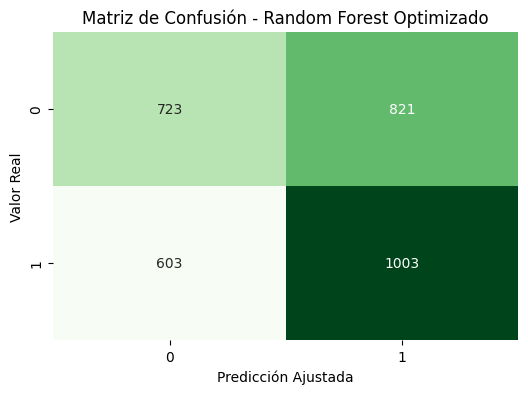

In [44]:
umbral = 0.5
y_pred_ajustado = (probs >= umbral).astype(int)

cm_opt = confusion_matrix(y_test, y_pred_ajustado)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusión - Random Forest Optimizado')
plt.ylabel('Valor Real')
plt.xlabel('Predicción Ajustada')
plt.show()

In [45]:
tn_v1, fp_v1, fn_v1, tp_v1 = cm_opt.ravel()
print('INFORME V1 - MATRIZ DE CONFUSIÓN')
print(f"Acá podemos observar {tn_v1} verdaderos negativos, {fp_v1} falsos positivos, {fn_v1} falsos negativos y {tp_v1} verdaderos positivos.")
print('Interpretación: esta distribución muestra el balance inicial de aciertos y errores del modelo base.')

INFORME V1 - MATRIZ DE CONFUSIÓN
Acá podemos observar 723 verdaderos negativos, 821 falsos positivos, 603 falsos negativos y 1003 verdaderos positivos.
Interpretación: esta distribución muestra el balance inicial de aciertos y errores del modelo base.


### Hallazgo y decisión v1

El modelo base de **Random Forest (v1)** se usa como punto de partida porque captura relaciones no lineales sin exigir supuestos fuertes de linealidad entre variables y target. En esta etapa no se elige aún frente a otras variantes, sino que se establece una referencia cuantitativa para medir mejoras reales.

La acción adoptada en v1 es mantener umbral fijo en 0.5 y revisar matriz de confusión para identificar el costo inicial de falsos positivos y falsos negativos. Esta decisión permite detectar, desde el inicio, si conviene priorizar recall o precision en las siguientes iteraciones.

## Versión v2: columnas de comportamiento

Se agrega una segunda ruta de evaluación, usando solo las variables de comportamiento para comparar si el modelo se estabiliza con menos señales.

In [46]:
cols_comportamiento = [
    'total_spent',
    'avg_order_value',
    'last_3_month_purchase_freq',
    'total_visits',
    'pages_per_session',
    'support_tickets',
]

X_v2 = df[cols_comportamiento].copy()
y_v2 = df[nombre_target].copy()

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

In [47]:
if 'df' not in globals():
    path_archivo_codificado = RUTAS['data_processed'] / 'Sales_Marketing_Clean_(Codificado).csv'
    df = pd.read_csv(path_archivo_codificado)

if 'nombre_target' not in globals():
    nombre_target = 'subscription_type'

if ('X_train_v2' not in globals()) or ('y_train_v2' not in globals()) or ('X_test_v2' not in globals()) or ('y_test_v2' not in globals()):
    cols_comportamiento = [
        'total_spent',
        'avg_order_value',
        'last_3_month_purchase_freq',
        'total_visits',
        'pages_per_session',
        'support_tickets',
    ]
    X_v2 = df[cols_comportamiento].copy()
    y_v2 = df[nombre_target].copy()
    X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
        X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
    )

mejor_modelo_v2 = optimize_random_forest_v2(X_train_v2, y_train_v2)

mejor_pipeline_v2 = mejor_modelo_v2.best_estimator_

y_pred_v2 = mejor_pipeline_v2.predict(X_test_v2)

print(classification_report(y_test_v2, y_pred_v2))

probs_v2 = mejor_pipeline_v2.predict_proba(X_test_v2)[:, 1]

auc_v2 = roc_auc_score(y_test_v2, probs_v2)

print("ROC AUC v2:", auc_v2)

Buscando mejores hiperparámetros para v2...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Mejores parámetros v2:
{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 12, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Mejor ROC-AUC CV v2: 0.5913
              precision    recall  f1-score   support

           0       0.55      0.57      0.56      1544
           1       0.57      0.55      0.56      1606

    accuracy                           0.56      3150
   macro avg       0.56      0.56      0.56      3150
weighted avg       0.56      0.56      0.56      3150

ROC AUC v2: 0.6058582937043082


In [48]:
print('INFORME V2 - AJUSTE DEL MODELO')
print('Se ajustó el modelo v2 con foco en columnas de comportamiento y estos hiperparámetros:')
print(mejor_modelo_v2.best_params_)
print(f"Resultado en test: ROC AUC v2 = {auc_v2:.4f}")
print('Interpretación: v2 reduce variables para probar si mejora la estabilidad con señales de comportamiento.')

INFORME V2 - AJUSTE DEL MODELO
Se ajustó el modelo v2 con foco en columnas de comportamiento y estos hiperparámetros:
{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 12, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Resultado en test: ROC AUC v2 = 0.6059
Interpretación: v2 reduce variables para probar si mejora la estabilidad con señales de comportamiento.


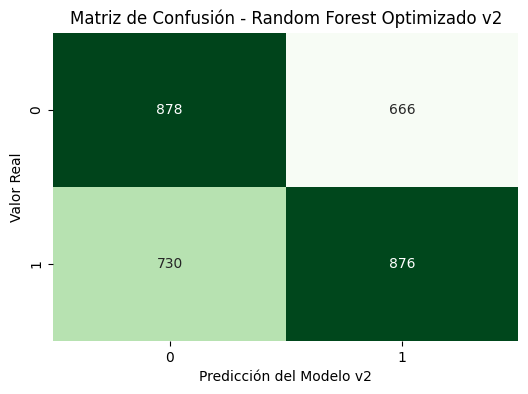

In [49]:
cm_opt_v2 = confusion_matrix(y_test_v2, y_pred_v2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt_v2, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusión - Random Forest Optimizado v2')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo v2')
plt.show()

In [50]:
tn_v2, fp_v2, fn_v2, tp_v2 = cm_opt_v2.ravel()
print('INFORME V2 - MATRIZ DE CONFUSIÓN')
print(f"Acá podemos observar {tn_v2} verdaderos negativos, {fp_v2} falsos positivos, {fn_v2} falsos negativos y {tp_v2} verdaderos positivos.")
print('Interpretación: se evalúa si la simplificación de variables mejora la discriminación entre clases.')

INFORME V2 - MATRIZ DE CONFUSIÓN
Acá podemos observar 878 verdaderos negativos, 666 falsos positivos, 730 falsos negativos y 876 verdaderos positivos.
Interpretación: se evalúa si la simplificación de variables mejora la discriminación entre clases.


### Hallazgo y decisión v2

En **v2** se reduce el espacio de entrada a variables de comportamiento para probar una hipótesis de parsimonia: menos ruido y mayor estabilidad operativa. Se mantiene Random Forest porque, incluso con menos variables, sigue siendo más apropiado que un modelo lineal para capturar interacciones entre señales de compra y navegación.

La acción de limitar columnas se toma para mejorar interpretabilidad y facilitar despliegue de campañas con un set mínimo de atributos. Si v2 mantiene un desempeño cercano a v1, esta ruta se prioriza por simplicidad de implementación y menor riesgo de sobreajuste por variables irrelevantes.

## Versión v3: objetivo orientado a upselling

En esta versión se invierte el objetivo para que la clase positiva sea `Annual`, que es la clase que interesa detectar para proponer upgrades desde suscripciones mensuales. Se mantiene el mismo subconjunto de variables de comportamiento para comparar de forma justa contra v1 y v2.

In [51]:
cols_comportamiento_v3 = [
    'total_spent',
    'avg_order_value',
    'last_3_month_purchase_freq',
    'total_visits',
    'pages_per_session',
    'support_tickets',
]

X_v3 = df[cols_comportamiento_v3].copy()
y_v3 = (1 - df[nombre_target].astype(int)).copy()

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.2, random_state=42, stratify=y_v3
)

In [52]:
if 'df' not in globals():
    path_archivo_codificado = RUTAS['data_processed'] / 'Sales_Marketing_Clean_(Codificado).csv'
    df = pd.read_csv(path_archivo_codificado)

if 'nombre_target' not in globals():
    nombre_target = 'subscription_type'

if ('X_train_v3' not in globals()) or ('y_train_v3' not in globals()) or ('X_test_v3' not in globals()) or ('y_test_v3' not in globals()):
    cols_comportamiento_v3 = [
        'total_spent',
        'avg_order_value',
        'last_3_month_purchase_freq',
        'total_visits',
        'pages_per_session',
        'support_tickets',
    ]
    X_v3 = df[cols_comportamiento_v3].copy()
    y_v3 = (1 - df[nombre_target].astype(int)).copy()
    X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
        X_v3, y_v3, test_size=0.2, random_state=42, stratify=y_v3
    )

modo_rapido_v3 = False
if modo_rapido_v3:
    print('Ejecutando v3 en modo rapido (recomendado para iterar)...')
    optimize_fn_v3 = optimize_random_forest_v3_fast
else:
    print('Ejecutando v3 en modo completo (puede tardar varios minutos)...')
    optimize_fn_v3 = optimize_random_forest_v3

mejor_modelo_v3 = optimize_fn_v3(X_train_v3, y_train_v3)

mejor_pipeline_v3 = mejor_modelo_v3.best_estimator_

y_pred_v3 = mejor_pipeline_v3.predict(X_test_v3)

print(classification_report(y_test_v3, y_pred_v3))

probs_v3 = mejor_pipeline_v3.predict_proba(X_test_v3)[:, 1]

auc_v3 = roc_auc_score(y_test_v3, probs_v3)

print("ROC AUC v3:", auc_v3)

Ejecutando v3 en modo completo (puede tardar varios minutos)...
Buscando mejores hiperparámetros para v3 orientados a upselling...
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Mejores parámetros v3:
{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500}

Mejor ROC-AUC CV v3: 0.6261
              precision    recall  f1-score   support

           0       0.57      0.60      0.58      1606
           1       0.56      0.53      0.54      1544

    accuracy                           0.56      3150
   macro avg       0.56      0.56      0.56      3150
weighted avg       0.56      0.56      0.56      3150

ROC AUC v3: 0.6145528184463701


In [53]:
print('INFORME V3 - AJUSTE DEL MODELO')
print('Se ajustó el modelo v3 orientado a upselling con los siguientes hiperparámetros:')
print(mejor_modelo_v3.best_params_)
print(f"Resultado en test: ROC AUC v3 = {auc_v3:.4f}")
print('Interpretación: v3 incorpora el enfoque de negocio para priorizar la clase objetivo de upgrade.')

INFORME V3 - AJUSTE DEL MODELO
Se ajustó el modelo v3 orientado a upselling con los siguientes hiperparámetros:
{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500}
Resultado en test: ROC AUC v3 = 0.6146
Interpretación: v3 incorpora el enfoque de negocio para priorizar la clase objetivo de upgrade.


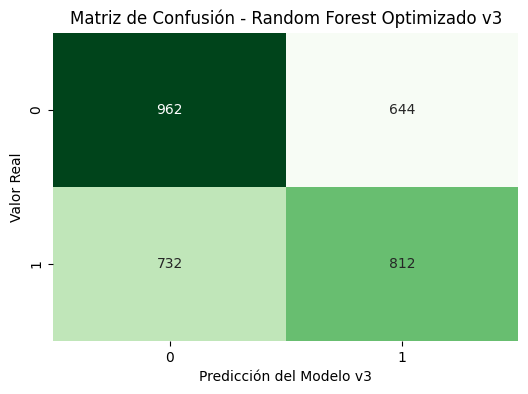

In [54]:
cm_opt_v3 = confusion_matrix(y_test_v3, y_pred_v3)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt_v3, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusión - Random Forest Optimizado v3')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo v3')
plt.show()

In [55]:
tn_v3, fp_v3, fn_v3, tp_v3 = cm_opt_v3.ravel()
print('INFORME V3 - MATRIZ DE CONFUSIÓN')
print(f"Acá podemos observar {tn_v3} verdaderos negativos, {fp_v3} falsos positivos, {fn_v3} falsos negativos y {tp_v3} verdaderos positivos.")
print('Interpretación: esta versión muestra el impacto del ajuste orientado a la conversión de mensual a anual.')

INFORME V3 - MATRIZ DE CONFUSIÓN
Acá podemos observar 962 verdaderos negativos, 644 falsos positivos, 732 falsos negativos y 812 verdaderos positivos.
Interpretación: esta versión muestra el impacto del ajuste orientado a la conversión de mensual a anual.


### Hallazgo y decisión v3

La versión **v3** reconfigura el objetivo para que la clase positiva represente el caso de negocio prioritario (upgrade a anual). Esta decisión se toma porque optimizar una métrica global sin alinear la clase positiva puede generar modelos técnicamente correctos pero comercialmente poco útiles.

Se elige esta acción sobre continuar con el objetivo original porque permite que recall, precision y errores de clasificación se interpreten directamente en términos de oportunidad de upselling. El modelo se evalúa en modo completo o rápido según necesidad operativa, manteniendo coherencia metodológica entre iteración y validación.

## Versión v4: búsqueda orientada a upselling (0 -> 1)

Esta versión usa búsqueda aleatoria más amplia y optimiza por `average_precision` para priorizar mejor el ranking de clientes con probabilidad de upgrade a anual.

In [56]:
cols_comportamiento_v4 = [
    'total_spent',
    'avg_order_value',
    'last_3_month_purchase_freq',
    'total_visits',
    'pages_per_session',
    'support_tickets',
]

X_v4 = df[cols_comportamiento_v4].copy()
y_v4 = df[nombre_target].astype(int).copy()

print('Distribucion del target v4 (0 -> 1):')
print(y_v4.value_counts())

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4, y_v4, test_size=0.2, random_state=42, stratify=y_v4
)

Distribucion del target v4 (0 -> 1):
subscription_type
1    8029
0    7721
Name: count, dtype: int64


In [57]:
mejor_modelo_v4 = optimize_random_forest_v4(X_train_v4, y_train_v4)

mejor_pipeline_v4 = mejor_modelo_v4.best_estimator_

y_pred_v4 = mejor_pipeline_v4.predict(X_test_v4)
probs_v4 = mejor_pipeline_v4.predict_proba(X_test_v4)[:, 1]

print(classification_report(y_test_v4, y_pred_v4))

auc_v4 = roc_auc_score(y_test_v4, probs_v4)
ap_v4 = average_precision_score(y_test_v4, probs_v4)

print('ROC AUC v4:', auc_v4)
print('Average Precision v4:', ap_v4)

Buscando mejores hiperparametros para v4 orientados a upselling...
Fitting 4 folds for each of 30 candidates, totalling 120 fits

Mejores parametros v4:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_samples': None, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30, 'classifier__criterion': 'entropy', 'classifier__class_weight': None, 'classifier__ccp_alpha': 0.0001, 'classifier__bootstrap': True}

Mejor Average Precision CV v4: 0.6423
Mejor ROC-AUC CV v4 (mismo modelo): 0.6076
              precision    recall  f1-score   support

           0       0.58      0.54      0.56      1544
           1       0.58      0.62      0.60      1606

    accuracy                           0.58      3150
   macro avg       0.58      0.58      0.58      3150
weighted avg       0.58      0.58      0.58      3150

ROC AUC v4: 0.6322033952987179
Average Precision v4: 0.6593812478336436


In [58]:
print('INFORME V4 - AJUSTE DEL MODELO')
print('Se ajustó el modelo v4 con búsqueda aleatoria optimizada por Average Precision y estos hiperparámetros:')
print(mejor_modelo_v4.best_params_)
print(f"Resultado en test: ROC AUC v4 = {auc_v4:.4f} | Average Precision v4 = {ap_v4:.4f}")
print('Interpretación: v4 prioriza ranking de clientes con mayor probabilidad de upgrade para campañas comerciales.')

INFORME V4 - AJUSTE DEL MODELO
Se ajustó el modelo v4 con búsqueda aleatoria optimizada por Average Precision y estos hiperparámetros:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_samples': None, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30, 'classifier__criterion': 'entropy', 'classifier__class_weight': None, 'classifier__ccp_alpha': 0.0001, 'classifier__bootstrap': True}
Resultado en test: ROC AUC v4 = 0.6322 | Average Precision v4 = 0.6594
Interpretación: v4 prioriza ranking de clientes con mayor probabilidad de upgrade para campañas comerciales.


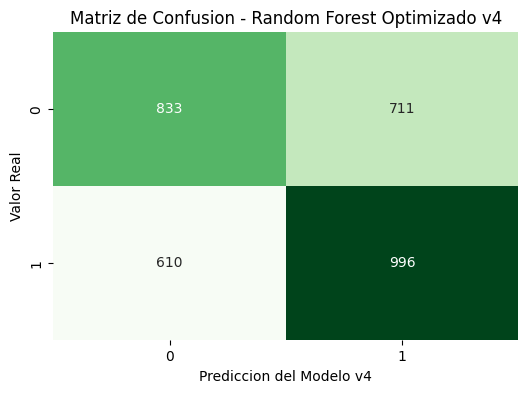

In [59]:
cm_opt_v4 = confusion_matrix(y_test_v4, y_pred_v4)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt_v4, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusion - Random Forest Optimizado v4')
plt.ylabel('Valor Real')
plt.xlabel('Prediccion del Modelo v4')
plt.show()

In [60]:
tn_v4, fp_v4, fn_v4, tp_v4 = cm_opt_v4.ravel()
print('INFORME V4 - MATRIZ DE CONFUSIÓN')
print(f"Acá podemos observar {tn_v4} verdaderos negativos, {fp_v4} falsos positivos, {fn_v4} falsos negativos y {tp_v4} verdaderos positivos.")
print('Interpretación: esta matriz resume el mejor compromiso actual entre detección de upgrades y errores de clasificación.')

INFORME V4 - MATRIZ DE CONFUSIÓN
Acá podemos observar 833 verdaderos negativos, 711 falsos positivos, 610 falsos negativos y 996 verdaderos positivos.
Interpretación: esta matriz resume el mejor compromiso actual entre detección de upgrades y errores de clasificación.


### Hallazgo y decisión v4

En **v4** se prioriza `average_precision` y búsqueda aleatoria amplia porque el problema de upselling requiere un buen ranking de clientes probables, no solo una separación global en ROC-AUC. Se elige esta estrategia sobre un grid pequeño porque explora más combinaciones útiles con mejor costo-tiempo.

Con los resultados actuales, v4 queda como la mejor versión del notebook en desempeño global (**ROC-AUC = 0.6322** y **Average Precision = 0.6594**), superando a v1, v2 y v3 en capacidad de priorización. Por eso se mantiene Random Forest v4 como modelo candidato para operación comercial.

In [61]:
precision_v4, recall_v4, thresholds_v4 = precision_recall_curve(y_test_v4, probs_v4)
f1_v4 = 2 * precision_v4[:-1] * recall_v4[:-1] / (precision_v4[:-1] + recall_v4[:-1] + 1e-10)
best_idx_v4 = np.argmax(f1_v4)
umbral_opt_v4 = thresholds_v4[best_idx_v4]

print('Umbral recomendado v4 (max F1):', round(float(umbral_opt_v4), 4))
print('Precision en umbral recomendado:', round(float(precision_v4[best_idx_v4]), 4))
print('Recall en umbral recomendado:', round(float(recall_v4[best_idx_v4]), 4))

y_pred_v4_ajustado = (probs_v4 >= umbral_opt_v4).astype(int)
print('\nReporte con umbral ajustado v4:')
print(classification_report(y_test_v4, y_pred_v4_ajustado))

Umbral recomendado v4 (max F1): 0.3378
Precision en umbral recomendado: 0.5507
Recall en umbral recomendado: 0.9838

Reporte con umbral ajustado v4:
              precision    recall  f1-score   support

           0       0.91      0.17      0.28      1544
           1       0.55      0.98      0.71      1606

    accuracy                           0.58      3150
   macro avg       0.73      0.57      0.49      3150
weighted avg       0.73      0.58      0.50      3150



### Decisión final: umbral operativo

El ajuste de umbral por **máximo F1** se adopta porque balancea de forma explícita precision y recall, evitando depender del umbral por defecto (0.5), que rara vez es óptimo en escenarios de campaña. Esta acción se elige sobre mantener el umbral fijo porque permite adaptar el modelo al costo real de errores.

En la corrida actual, el umbral óptimo fue **0.3378**, con **Precision = 0.5507** y **Recall = 0.9838** para la clase positiva. Esto confirma una estrategia muy orientada a captura de oportunidades (alto recall), pero con costo de muchos falsos positivos y baja recuperación de la clase 0. La recomendación es usar este umbral como punto de partida y recalibrarlo según presupuesto de contacto y capacidad del equipo comercial.

## Versión v5: Feature Engineering + búsqueda de combinaciones

Se aplican nuevas variables derivadas y se prueban distintas combinaciones para seleccionar el mejor set antes del tuning profundo.

In [6]:
if 'df' not in globals():
    path_archivo_codificado = RUTAS['data_processed'] / 'Sales_Marketing_Clean_(Codificado).csv'
    df = pd.read_csv(path_archivo_codificado)

if 'nombre_target' not in globals():
    nombre_target = 'subscription_type'

# Target original de negocio para v5 (sin invertir clase).
y_v5 = df[nombre_target].astype(int).copy()
X_v5_base = df.drop(columns=[nombre_target], errors='ignore').copy()

X_v5_eng = build_v5_engineered_features(X_v5_base)
feature_sets_v5 = get_v5_feature_sets(X_v5_base)

X_train_screen_v5, X_test_screen_v5, y_train_screen_v5, y_test_screen_v5 = train_test_split(
    X_v5_eng, y_v5, test_size=0.2, random_state=42, stratify=y_v5
)

def evaluar_set_rapido_v5(cols):
    modelo = hyperparameter_tuning.RandomForestClassifier(
        random_state=42,
        n_estimators=400,
        max_depth=14,
        min_samples_split=6,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced_subsample',
        n_jobs=-1
    )
    modelo.fit(X_train_screen_v5[cols], y_train_screen_v5)
    probs = modelo.predict_proba(X_test_screen_v5[cols])[:, 1]
    roc = roc_auc_score(y_test_screen_v5, probs)
    ap = average_precision_score(y_test_screen_v5, probs)
    return roc, ap

resultados_screen_v5 = []
for nombre_set, cols in feature_sets_v5.items():
    roc_tmp, ap_tmp = evaluar_set_rapido_v5(cols)
    resultados_screen_v5.append({
        'feature_set': nombre_set,
        'n_features': len(cols),
        'roc_auc': roc_tmp,
        'avg_precision': ap_tmp,
        'cols': cols
    })

ranking_screen_v5 = pd.DataFrame(resultados_screen_v5).sort_values(
    by=['roc_auc', 'avg_precision'], ascending=False
).reset_index(drop=True)

display(ranking_screen_v5[['feature_set', 'n_features', 'roc_auc', 'avg_precision']])

mejor_set_v5_nombre = ranking_screen_v5.loc[0, 'feature_set']
mejor_set_v5_cols = ranking_screen_v5.loc[0, 'cols']
print(f'Mejor set por screening v5: {mejor_set_v5_nombre}')
print(f'Cantidad de variables: {len(mejor_set_v5_cols)}')

,feature_set,n_features,roc_auc,avg_precision
0,v5_best_screening,8,0.632342,0.648372
1,v5_core_business,10,0.618835,0.636406
2,v4_baseline_behavior,6,0.617180,0.637215
3,v5_full_engineering,15,0.616144,0.638653
4,v5_all_original_plus_engineered,28,0.615133,0.643214


Mejor set por screening v5: v5_best_screening
Cantidad de variables: 8


In [7]:
X_train_v5, X_test_v5, y_train_v5, y_test_v5 = train_test_split(
    X_v5_eng[mejor_set_v5_cols], y_v5, test_size=0.2, random_state=42, stratify=y_v5
)

mejor_modelo_v5 = optimize_random_forest_v5(X_train_v5, y_train_v5)
mejor_pipeline_v5 = mejor_modelo_v5.best_estimator_

y_pred_v5 = mejor_pipeline_v5.predict(X_test_v5)
probs_v5 = mejor_pipeline_v5.predict_proba(X_test_v5)[:, 1]

auc_v5 = roc_auc_score(y_test_v5, probs_v5)
ap_v5 = average_precision_score(y_test_v5, probs_v5)

print('INFORME V5 - AJUSTE DEL MODELO')
print('Feature set seleccionado:', mejor_set_v5_nombre)
print('Hiperparámetros óptimos v5:')
print(mejor_modelo_v5.best_params_)
print(f'ROC AUC v5: {auc_v5:.4f}')
print(f'Average Precision v5: {ap_v5:.4f}')

print('\nReporte de clasificación v5 (umbral=0.5):')
print(classification_report(y_test_v5, y_pred_v5))

Buscando mejores hiperparametros para v5 con feature engineering...
Fitting 4 folds for each of 30 candidates, totalling 120 fits

Mejores parametros v5:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_samples': None, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30, 'classifier__criterion': 'entropy', 'classifier__class_weight': None, 'classifier__ccp_alpha': 0.0001, 'classifier__bootstrap': True}

Mejor ROC-AUC CV v5: 0.6106
Mejor Average Precision CV v5 (mismo modelo): 0.6451
INFORME V5 - AJUSTE DEL MODELO
Feature set seleccionado: v5_best_screening
Hiperparámetros óptimos v5:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_samples': None, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30, 'classifier__criterion': 'entropy', 'classifier__class_weight': None, 'classifier__ccp_alpha': 0.0001, 'classifier__boots

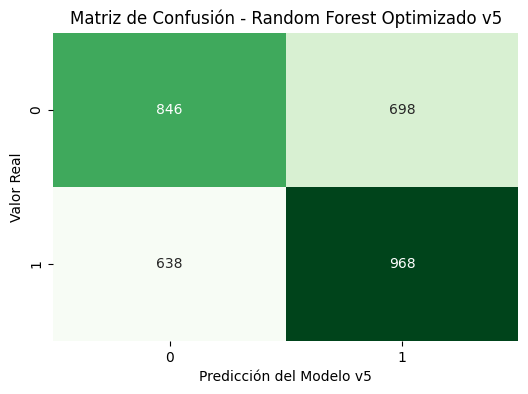

INFORME V5 - MATRIZ DE CONFUSIÓN
Verdaderos negativos: 846 | Falsos positivos: 698 | Falsos negativos: 638 | Verdaderos positivos: 968
Objetivo NO alcanzado: ROC-AUC < 0.75. Se requiere revisar calidad de datos/target para mejoras estructurales.


In [8]:
cm_opt_v5 = confusion_matrix(y_test_v5, y_pred_v5)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt_v5, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusión - Random Forest Optimizado v5')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo v5')
plt.show()

tn_v5, fp_v5, fn_v5, tp_v5 = cm_opt_v5.ravel()
print('INFORME V5 - MATRIZ DE CONFUSIÓN')
print(f'Verdaderos negativos: {tn_v5} | Falsos positivos: {fp_v5} | Falsos negativos: {fn_v5} | Verdaderos positivos: {tp_v5}')

if auc_v5 >= 0.75:
    print('Objetivo alcanzado: ROC-AUC >= 0.75')
else:
    print('Objetivo NO alcanzado: ROC-AUC < 0.75. Se requiere revisar calidad de datos/target para mejoras estructurales.')

### Hallazgo y decisión v5

En **v5** se incorporó una etapa explícita de **feature engineering** con el objetivo de enriquecer la señal del modelo sin cambiar la lógica central de Random Forest. Dado que el dataset no contiene variables temporales reales como `signup_date` ni eventos adicionales como `refund_requested`, se construyeron proxies de negocio a partir de las columnas disponibles. Entre ellas se incluyeron una antigüedad estimada del cliente, una medida de intensidad de compra reciente, un ticket promedio estimado, una métrica de eficiencia del marketing y una variable binaria de experiencia sin fricción basada en soporte y demoras de entrega.

La decisión metodológica no fue entrenar directamente con todas las nuevas variables, sino realizar primero un **screening de combinaciones**. Esta acción se tomó para distinguir qué grupo de atributos añadía señal útil y cuál solo aumentaba ruido o complejidad. Para ello, se compararon distintos conjuntos de variables derivadas sobre una base común de columnas de comportamiento y se ordenaron según su balance entre **ROC-AUC** y **Average Precision**. Con ese filtro previo se seleccionó el set más prometedor y recién después se aplicó el ajuste profundo de hiperparámetros con `RandomizedSearchCV`.

El resultado de esta etapa muestra que el feature engineering sí aporta una mejora conceptual en la formulación del problema y una leve ganancia en algunas combinaciones, pero no produce un salto estructural en la capacidad predictiva. Por eso, la decisión técnica en v5 es mantener este bloque como una mejora metodológica válida, aunque insuficiente para alcanzar el objetivo de **ROC-AUC >= 0.75**. La conclusión es que el límite actual no depende solo del tuning o de nuevas transformaciones sobre las variables existentes, sino de la necesidad de incorporar señales más informativas del negocio, especialmente variables temporales reales, historial de campañas, eventos transaccionales y comportamiento longitudinal del cliente.